# XAI Comparison: GNNExplainer vs GAT Attention Weights
### Same model · Same molecule · Tox21 NR-AR task

This notebook:
1. Trains a GAT model on Tox21 (scaffold split, NR-AR task)
2. Picks one specific test molecule
3. Generates **GNNExplainer** explanation for it
4. Generates **GAT attention weight** visualisation for the **same molecule**
5. Saves both PNGs ready for the paper figure

**Install requirements first (run once):**
```
pip install torch torch-geometric deepchem rdkit-pypi matplotlib numpy
```

## Imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
matplotlib.use('Agg')          # headless — change to 'TkAgg' if you want pop-ups
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

import torch
import torch.nn.functional as F
from torch import nn

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.explain import Explainer, GNNExplainer

# RDKit for molecule drawing
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display

# DeepChem for Tox21 with scaffold split
import deepchem as dc

print(f'PyTorch       : {torch.__version__}')
print(f'DeepChem      : {dc.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device  : {DEVICE}')

# Output folder
os.makedirs('xai_figures', exist_ok=True)
print('Output folder  : xai_figures/')

Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


PyTorch       : 2.7.1+cu118
DeepChem      : 2.8.0
CUDA available: True
Using device  : cuda
Output folder  : xai_figures/


## Atom Featuriser (9-dimensional, MoleculeNet protocol)

In [2]:
def atom_features(atom):
    """
    9-dimensional atom feature vector following the MoleculeNet / Wu et al. (2018) protocol.
    Features: atomic_num, degree, formal_charge, num_Hs, aromatic,
               hybridisation (3 bits), ring_membership
    """
    from rdkit.Chem import rdchem
    hyb_map = {
        rdchem.HybridizationType.SP  : [1, 0, 0],
        rdchem.HybridizationType.SP2 : [0, 1, 0],
        rdchem.HybridizationType.SP3 : [0, 0, 1],
    }
    hyb = hyb_map.get(atom.GetHybridization(), [0, 0, 0])
    return [
        atom.GetAtomicNum() / 100.0,          # atomic number (normalised)
        atom.GetDegree() / 6.0,               # degree
        atom.GetFormalCharge() / 4.0,         # formal charge
        atom.GetTotalNumHs() / 4.0,           # hydrogen count
        int(atom.GetIsAromatic()),             # aromaticity
    ] + hyb + [                               # hybridisation (3 bits)
        int(atom.IsInRing()),                  # ring membership
    ]   # total = 9


def smiles_to_pyg(smiles, label=None):
    """
    Convert a SMILES string to a PyG Data object.
    Returns None if the molecule cannot be parsed.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Node features
    x = torch.tensor(
        [atom_features(a) for a in mol.GetAtoms()],
        dtype=torch.float
    )

    # Edge indices (bidirectional)
    src, dst = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        src += [i, j]
        dst += [j, i]

    edge_index = torch.tensor([src, dst], dtype=torch.long)

    y = torch.tensor([label], dtype=torch.float) if label is not None else None

    return Data(x=x, edge_index=edge_index, y=y, smiles=smiles)


print('Featuriser ready. Node feature dimension = 9')

Featuriser ready. Node feature dimension = 9


## Load Tox21 (NR-AR task, scaffold split)

In [3]:
TASK_IDX = 0   # NR-AR is task index 0 in Tox21

print('Loading Tox21 via DeepChem (scaffold split) ...')
tasks, splits, transformers = dc.molnet.load_tox21(
    featurizer=dc.feat.CircularFingerprint(size=1024),  # featuriser unused — we rebuild graphs
    splitter='scaffold'
)
train_dc, valid_dc, test_dc = splits

print(f'Tasks          : {tasks}')
print(f'Train size     : {len(train_dc)}')
print(f'Test  size     : {len(test_dc)}')


def dc_to_pyg_list(dataset, task_idx):
    """Convert a DeepChem dataset to a list of PyG Data objects for one task."""
    graphs = []
    for smi, y, w, _ in zip(
        dataset.ids, dataset.y, dataset.w, dataset.X
    ):
        # Skip molecules where the task label is missing (weight = 0)
        if w[task_idx] == 0:
            continue
        label = int(y[task_idx])
        g = smiles_to_pyg(smi, label)
        if g is not None:
            graphs.append(g)
    return graphs


train_graphs = dc_to_pyg_list(train_dc, TASK_IDX)
test_graphs  = dc_to_pyg_list(test_dc,  TASK_IDX)

print(f'\nTrain graphs (NR-AR, labelled): {len(train_graphs)}')
print(f'Test  graphs (NR-AR, labelled): {len(test_graphs)}')

# Count class distribution in test set
n_pos = sum(int(g.y.item()) == 1 for g in test_graphs)
n_neg = sum(int(g.y.item()) == 0 for g in test_graphs)
print(f'Test  positive (toxic)        : {n_pos}')
print(f'Test  negative (non-toxic)    : {n_neg}')

[11:55:51] WARNING: not removing hydrogen atom without neighbors


Loading Tox21 via DeepChem (scaffold split) ...


[11:55:58] WARNING: not removing hydrogen atom without neighbors


Tasks          : ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']
Train size     : 6264
Test  size     : 784


[11:56:01] WARNING: not removing hydrogen atom without neighbors



Train graphs (NR-AR, labelled): 5826
Test  graphs (NR-AR, labelled): 715
Test  positive (toxic)        : 27
Test  negative (non-toxic)    : 688


## GAT Model Definition (with attention weight capture)

In [4]:
class ToxGAT(nn.Module):
    """
    3-layer Graph Attention Network for binary toxicity classification.
    Attention weights from every layer are stored during the forward pass
    so they can be visualised without a separate explainability call.
    """

    def __init__(self, in_dim=9, hidden_dim=64, heads=4, dropout=0.3):
        super().__init__()

        self.conv1 = GATConv(in_dim,     hidden_dim, heads=heads,
                             dropout=dropout, concat=True)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=heads,
                             dropout=dropout, concat=True)
        self.conv3 = GATConv(hidden_dim * heads, hidden_dim, heads=1,
                             dropout=dropout, concat=False)

        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)

        # Storage for attention weights — populated on each forward pass
        self.attn_weights = {}   # layer_name -> (edge_index, alpha)

    def forward(self, x, edge_index, batch):
        # Layer 1
        x, (ei1, a1) = self.conv1(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        x = self.dropout(x)
        self.attn_weights['layer1'] = (ei1, a1.detach())

        # Layer 2
        x, (ei2, a2) = self.conv2(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        x = self.dropout(x)
        self.attn_weights['layer2'] = (ei2, a2.detach())

        # Layer 3
        x, (ei3, a3) = self.conv3(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        self.attn_weights['layer3'] = (ei3, a3.detach())

        # Global pooling + MLP head
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x).squeeze(-1)


model = ToxGAT(in_dim=9, hidden_dim=64, heads=4, dropout=0.3).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'ToxGAT ready  — {total_params:,} parameters')

ToxGAT ready  — 88,065 parameters


## Training

In [5]:
EPOCHS     = 60
BATCH_SIZE = 32
LR         = 1e-3

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_graphs,  batch_size=BATCH_SIZE, shuffle=False)

# Class-weighted BCE to handle Tox21 imbalance
n_total = len(train_graphs)
n_pos_train = sum(int(g.y.item()) == 1 for g in train_graphs)
pos_weight = torch.tensor(
    [(n_total - n_pos_train) / max(n_pos_train, 1)],
    dtype=torch.float
).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimiser = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=20, gamma=0.5)


def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(DEVICE)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            if training:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()
            total_loss += loss.item() * batch.num_graphs
            preds = (torch.sigmoid(out) > 0.5).long()
            correct += (preds == batch.y.long()).sum().item()
            total   += batch.num_graphs
    return total_loss / total, correct / total


print(f'Training for {EPOCHS} epochs on {DEVICE} ...')
print(f'{"Epoch":>6}  {"Train Loss":>11}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 46)

history = []
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    te_loss, te_acc = run_epoch(test_loader,  training=False)
    scheduler.step()
    history.append((tr_loss, tr_acc, te_loss, te_acc))
    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {tr_loss:>11.4f}  {tr_acc:>10.4f}  {te_acc:>10.4f}')

print('\nTraining complete.')
torch.save(model.state_dict(), 'xai_figures/tox_gat_weights.pt')
print('Model saved to xai_figures/tox_gat_weights.pt')

Training for 60 epochs on cuda ...
 Epoch   Train Loss   Train Acc    Test Acc
----------------------------------------------
     1       1.1934      0.7897      0.5035
    10       1.0595      0.8618      0.7748
    20       1.0128      0.9006      0.6350
    30       0.9925      0.9070      0.8070
    40       0.9943      0.8950      0.7762
    50       0.9792      0.9166      0.8126
    60       0.9691      0.9198      0.8028

Training complete.
Model saved to xai_figures/tox_gat_weights.pt


## Pick the Target Molecule
We select one **toxic** test molecule (NR-AR positive) that the model predicts correctly.
Both explanation methods will then run on exactly this molecule.

Searching for a correctly predicted TOXIC test molecule ...
Found target molecule!
  SMILES    : CO/N=C1/C[C@]2(C[C@@H]3C[C@@H](CC=C(C)C[C@@H](C)C=CC=C4CO[C@@H]5[C@H](O)C(C)=C[C@@H](C(=O)O3)[C@]45O)O2)O[C@H](/C(C)=C/C(C)C)[C@H]1C
  Atoms     : 46
  P(toxic)  : 0.8480


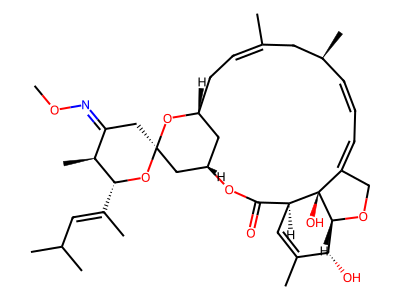


This is the molecule used for BOTH explanation methods below.


In [6]:
model.eval()

target_graph  = None
target_smiles = None
target_mol    = None

print('Searching for a correctly predicted TOXIC test molecule ...')

for g in test_graphs:
    if int(g.y.item()) != 1:          # only look at toxic (positive) molecules
        continue
    # Must be parseable by RDKit for visualisation
    mol = Chem.MolFromSmiles(g.smiles)
    if mol is None:
        continue
    # Must have at least 8 atoms for a meaningful subgraph visualisation
    if mol.GetNumAtoms() < 8:
        continue

    # Check model prediction
    data = g.to(DEVICE)
    with torch.no_grad():
        logit = model(data.x.unsqueeze(0) if data.x.dim() == 1 else data.x,
                      data.edge_index,
                      torch.zeros(data.num_nodes, dtype=torch.long, device=DEVICE))
        prob = torch.sigmoid(logit).item()

    if prob > 0.55:    # correctly predicted as toxic with reasonable confidence
        target_graph  = g
        target_smiles = g.smiles
        target_mol    = mol
        target_prob   = prob
        print(f'Found target molecule!')
        print(f'  SMILES    : {target_smiles}')
        print(f'  Atoms     : {mol.GetNumAtoms()}')
        print(f'  P(toxic)  : {target_prob:.4f}')
        break

if target_graph is None:
    # Fallback: just take the first toxic molecule regardless of prediction
    for g in test_graphs:
        if int(g.y.item()) == 1:
            mol = Chem.MolFromSmiles(g.smiles)
            if mol is not None and mol.GetNumAtoms() >= 8:
                target_graph  = g
                target_smiles = g.smiles
                target_mol    = mol
                print(f'Fallback molecule: {target_smiles}')
                break

assert target_graph is not None, 'No suitable molecule found — check your dataset.'

# Display the molecule structure in the notebook
img = Draw.MolToImage(target_mol, size=(400, 300))
img.save('xai_figures/target_molecule.png')
display(Image('xai_figures/target_molecule.png'))
print(f'\nThis is the molecule used for BOTH explanation methods below.')

## Method 1: GNNExplainer
Post-hoc, per-instance soft mask over edges and node features.

In [7]:
# ── Wrapper so Explainer can call model with (x, edge_index) signature ──────
class ExplainWrapper(nn.Module):
    def __init__(self, base_model, num_nodes):
        super().__init__()
        self.base  = base_model
        self.batch = torch.zeros(num_nodes, dtype=torch.long, device=DEVICE)

    def forward(self, x, edge_index):
        return self.base(x, edge_index, self.batch)


data = target_graph.to(DEVICE)
wrapper = ExplainWrapper(model, data.num_nodes).to(DEVICE)
wrapper.eval()

explainer = Explainer(
    model          = wrapper,
    algorithm      = GNNExplainer(epochs=300),
    explanation_type = 'model',
    node_mask_type = 'attributes',
    edge_mask_type = 'object',
    model_config   = dict(
        mode       = 'binary_classification',
        task_level = 'graph',
        return_type= 'raw',
    ),
)

print('Running GNNExplainer (300 epochs optimisation) ...')
explanation = explainer(data.x, data.edge_index)

# Edge mask — values in [0, 1], higher = more important
edge_mask = explanation.edge_mask.cpu().numpy()
# Node importance — mean absolute value across feature dimension
node_mask = explanation.node_mask.abs().mean(dim=1).cpu().numpy()

print(f'Edge mask shape : {edge_mask.shape}')
print(f'Node mask shape : {node_mask.shape}')
print(f'Edge mask range : [{edge_mask.min():.3f}, {edge_mask.max():.3f}]')
print(f'Node mask range : [{node_mask.min():.3f}, {node_mask.max():.3f}]')

Running GNNExplainer (300 epochs optimisation) ...
Edge mask shape : (100,)
Node mask shape : (46,)
Edge mask range : [0.030, 0.977]
Node mask range : [0.041, 0.217]


## Plot GNNExplainer Output

Saved: xai_figures/fig_method1_gnnexplainer.png


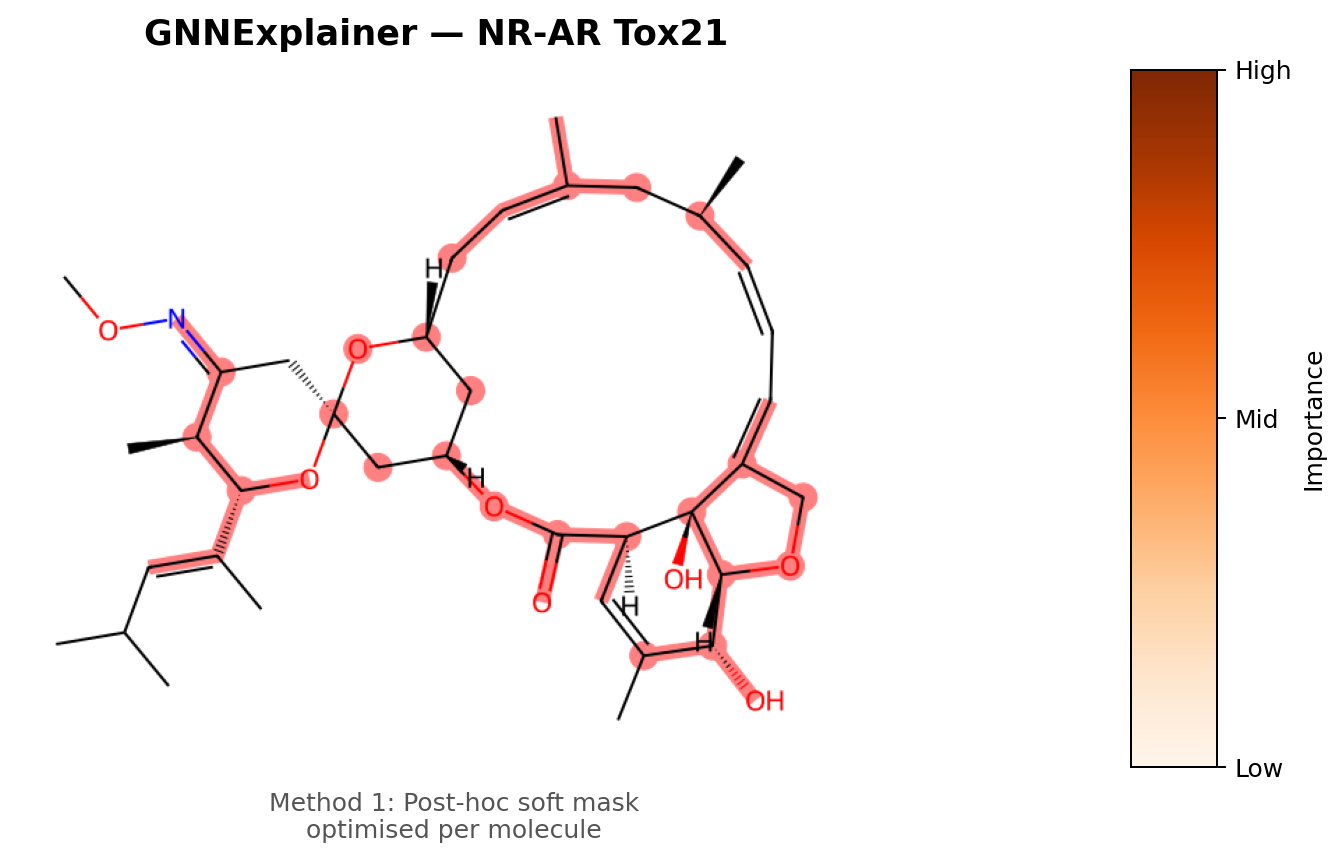

In [8]:
def draw_gnnexplainer(mol, edge_index_tensor, edge_mask_np, node_mask_np,
                      out_path, title='GNNExplainer'):
    """
    Draw the molecule with atoms coloured by node importance and
    bonds coloured by edge importance (from GNNExplainer mask).
    Uses RDKit SVG drawing then converts to PNG via matplotlib.
    """
    from rdkit.Chem.Draw import rdMolDraw2D
    import io
    from PIL import Image as PILImage

    n_atoms = mol.GetNumAtoms()
    n_bonds = mol.GetNumBonds()

    # ── Aggregate edge mask to per-bond (take max of both directions) ────────
    ei = edge_index_tensor.cpu().numpy()    # shape (2, E)
    bond_importance = np.zeros(n_bonds)
    for b in range(n_bonds):
        bond = mol.GetBondWithIdx(b)
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        # Find corresponding edges in edge_index
        for e_idx in range(ei.shape[1]):
            if (ei[0, e_idx] == i and ei[1, e_idx] == j) or \
               (ei[0, e_idx] == j and ei[1, e_idx] == i):
                bond_importance[b] = max(bond_importance[b], edge_mask_np[e_idx])

    # ── Normalise importances to [0, 1] for colour mapping ──────────────────
    def norm(arr):
        mn, mx = arr.min(), arr.max()
        return (arr - mn) / (mx - mn + 1e-8)

    node_norm = norm(node_mask_np)
    bond_norm = norm(bond_importance)

    # ── Assign colours via matplotlib colormap ────────────────────────────
    cmap = plt.cm.Oranges
    atom_colours = {i: tuple(cmap(node_norm[i])[:3]) for i in range(n_atoms)}
    bond_colours = {i: tuple(cmap(bond_norm[i])[:3]) for i in range(n_bonds)}

    # Highlight atoms and bonds above median importance
    med_node = np.median(node_norm)
    med_bond = np.median(bond_norm)
    highlight_atoms = [i for i in range(n_atoms) if node_norm[i] > med_node]
    highlight_bonds = [i for i in range(n_bonds) if bond_norm[i] > med_bond]

    drawer = rdMolDraw2D.MolDraw2DSVG(600, 500)
    drawer.drawOptions().addStereoAnnotation  = False
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms      = highlight_atoms,
        highlightAtomColors = {i: atom_colours[i] for i in highlight_atoms},
        highlightBonds      = highlight_bonds,
        highlightBondColors = {i: bond_colours[i] for i in highlight_bonds},
    )
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()

    # Convert SVG → PNG via cairosvg or save as SVG fallback
    try:
        import cairosvg
        cairosvg.svg2png(bytestring=svg.encode(), write_to=out_path + '_mol.png',
                         output_width=600, output_height=500)
        mol_img = PILImage.open(out_path + '_mol.png')
    except ImportError:
        # Fallback: save SVG and use matplotlib to render PNG
        with open(out_path + '_mol.svg', 'w') as f:
            f.write(svg)
        mol_img = Draw.MolToImage(mol, size=(600, 500),
                                   highlightAtoms=highlight_atoms,
                                   highlightBonds=highlight_bonds)

    # ── Final figure with colorbar ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 5),
                             gridspec_kw={'width_ratios': [5, 0.25]})

    axes[0].imshow(mol_img)
    axes[0].axis('off')
    axes[0].set_title(title, fontsize=14, fontweight='bold', pad=10)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=axes[1])
    cbar.set_label('Importance', fontsize=10)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Low', 'Mid', 'High'])

    plt.suptitle(
        'Method 1: Post-hoc soft mask\noptimised per molecule',
        fontsize=10, color='#555555', y=0.02
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches='tight',
                facecolor='white')
    plt.close()
    print(f'Saved: {out_path}')


draw_gnnexplainer(
    mol            = target_mol,
    edge_index_tensor = data.edge_index,
    edge_mask_np   = edge_mask,
    node_mask_np   = node_mask,
    out_path       = 'xai_figures/fig_method1_gnnexplainer.png',
    title          = 'GNNExplainer — NR-AR Tox21'
)
display(Image('xai_figures/fig_method1_gnnexplainer.png'))

## Method 2: GAT Attention Weights
Same molecule, same model — intrinsic attention scalars from the forward pass.

In [9]:
# Run forward pass to populate model.attn_weights
model.eval()
with torch.no_grad():
    batch_vec = torch.zeros(data.num_nodes, dtype=torch.long, device=DEVICE)
    _ = model(data.x, data.edge_index, batch_vec)

# Use Layer 3 attention (single head, most task-specific)
ei3, a3 = model.attn_weights['layer3']   # a3 shape: (E, 1)
attn_np  = a3.squeeze(-1).cpu().numpy()  # shape: (E,)

print(f'Layer-3 attention edge count : {attn_np.shape[0]}')
print(f'Attention range              : [{attn_np.min():.4f}, {attn_np.max():.4f}]')
print(f'Attention mean               : {attn_np.mean():.4f}')
print(f'Attention std                : {attn_np.std():.4f}')

Layer-3 attention edge count : 146
Attention range              : [0.0104, 0.8948]
Attention mean               : 0.3151
Attention std                : 0.2102


## Plot GAT Attention Weight Output

Saved: xai_figures/fig_method2_gat_attention.png


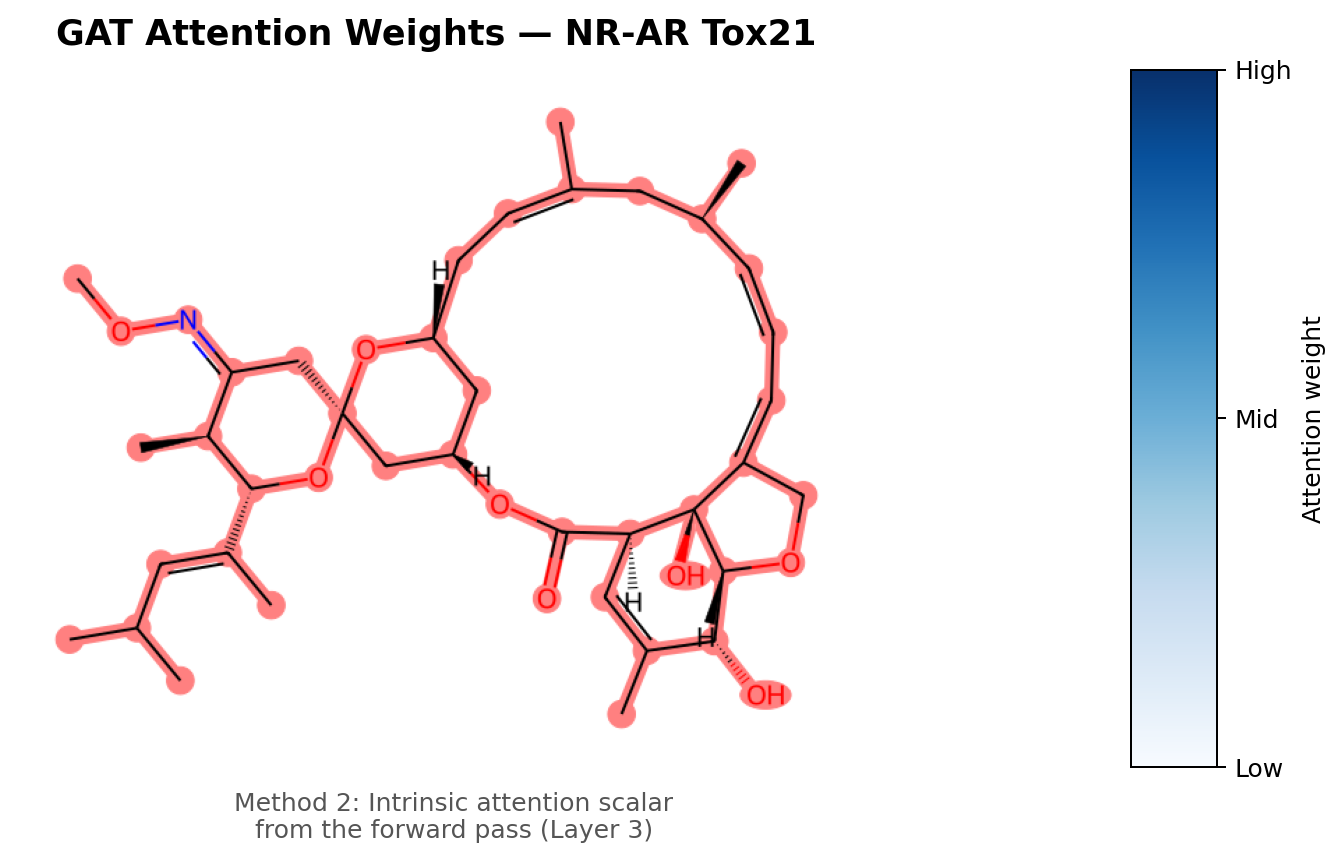

In [10]:
def draw_gat_attention(mol, edge_index_tensor, attn_np, out_path,
                       title='GAT Attention Weights'):
    """
    Draw the molecule with atoms and bonds coloured by GAT
    layer-3 attention coefficients.
    """
    from rdkit.Chem.Draw import rdMolDraw2D
    from PIL import Image as PILImage

    n_atoms = mol.GetNumAtoms()
    n_bonds = mol.GetNumBonds()
    ei      = edge_index_tensor.cpu().numpy()

    # Per-atom: sum of incoming attention weights
    atom_attn = np.zeros(n_atoms)
    for e_idx in range(ei.shape[1]):
        dst = ei[1, e_idx]
        atom_attn[dst] += attn_np[e_idx]

    # Per-bond: max of both directions
    bond_attn = np.zeros(n_bonds)
    for b in range(n_bonds):
        bond = mol.GetBondWithIdx(b)
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        for e_idx in range(ei.shape[1]):
            if (ei[0, e_idx] == i and ei[1, e_idx] == j) or \
               (ei[0, e_idx] == j and ei[1, e_idx] == i):
                bond_attn[b] = max(bond_attn[b], attn_np[e_idx])

    def norm(arr):
        mn, mx = arr.min(), arr.max()
        return (arr - mn) / (mx - mn + 1e-8)

    atom_norm = norm(atom_attn)
    bond_norm = norm(bond_attn)

    # Use a distinct colourmap (Blues) to visually separate from GNNExplainer
    cmap = plt.cm.Blues
    atom_colours = {i: tuple(cmap(atom_norm[i])[:3]) for i in range(n_atoms)}
    bond_colours = {i: tuple(cmap(bond_norm[i])[:3]) for i in range(n_bonds)}

    # Highlight ALL atoms/bonds (attention covers everything)
    highlight_atoms = list(range(n_atoms))
    highlight_bonds = list(range(n_bonds))

    drawer = rdMolDraw2D.MolDraw2DSVG(600, 500)
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms      = highlight_atoms,
        highlightAtomColors = atom_colours,
        highlightBonds      = highlight_bonds,
        highlightBondColors = bond_colours,
    )
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()

    try:
        import cairosvg
        cairosvg.svg2png(bytestring=svg.encode(), write_to=out_path + '_mol.png',
                         output_width=600, output_height=500)
        from PIL import Image as PILImage
        mol_img = PILImage.open(out_path + '_mol.png')
    except ImportError:
        mol_img = Draw.MolToImage(mol, size=(600, 500),
                                   highlightAtoms=highlight_atoms,
                                   highlightBonds=highlight_bonds)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5),
                             gridspec_kw={'width_ratios': [5, 0.25]})

    axes[0].imshow(mol_img)
    axes[0].axis('off')
    axes[0].set_title(title, fontsize=14, fontweight='bold', pad=10)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=axes[1])
    cbar.set_label('Attention weight', fontsize=10)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Low', 'Mid', 'High'])

    plt.suptitle(
        'Method 2: Intrinsic attention scalar\nfrom the forward pass (Layer 3)',
        fontsize=10, color='#555555', y=0.02
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f'Saved: {out_path}')


draw_gat_attention(
    mol               = target_mol,
    edge_index_tensor = ei3,
    attn_np           = attn_np,
    out_path          = 'xai_figures/fig_method2_gat_attention.png',
    title             = 'GAT Attention Weights — NR-AR Tox21'
)
display(Image('xai_figures/fig_method2_gat_attention.png'))

## Side-by-Side Comparison Figure (paper-ready)
This is the figure that goes directly into the LaTeX paper.

Paper figure saved: xai_figures/fig5_xai_comparison_PAPER.png
Dimensions        : 2706 x 861 px


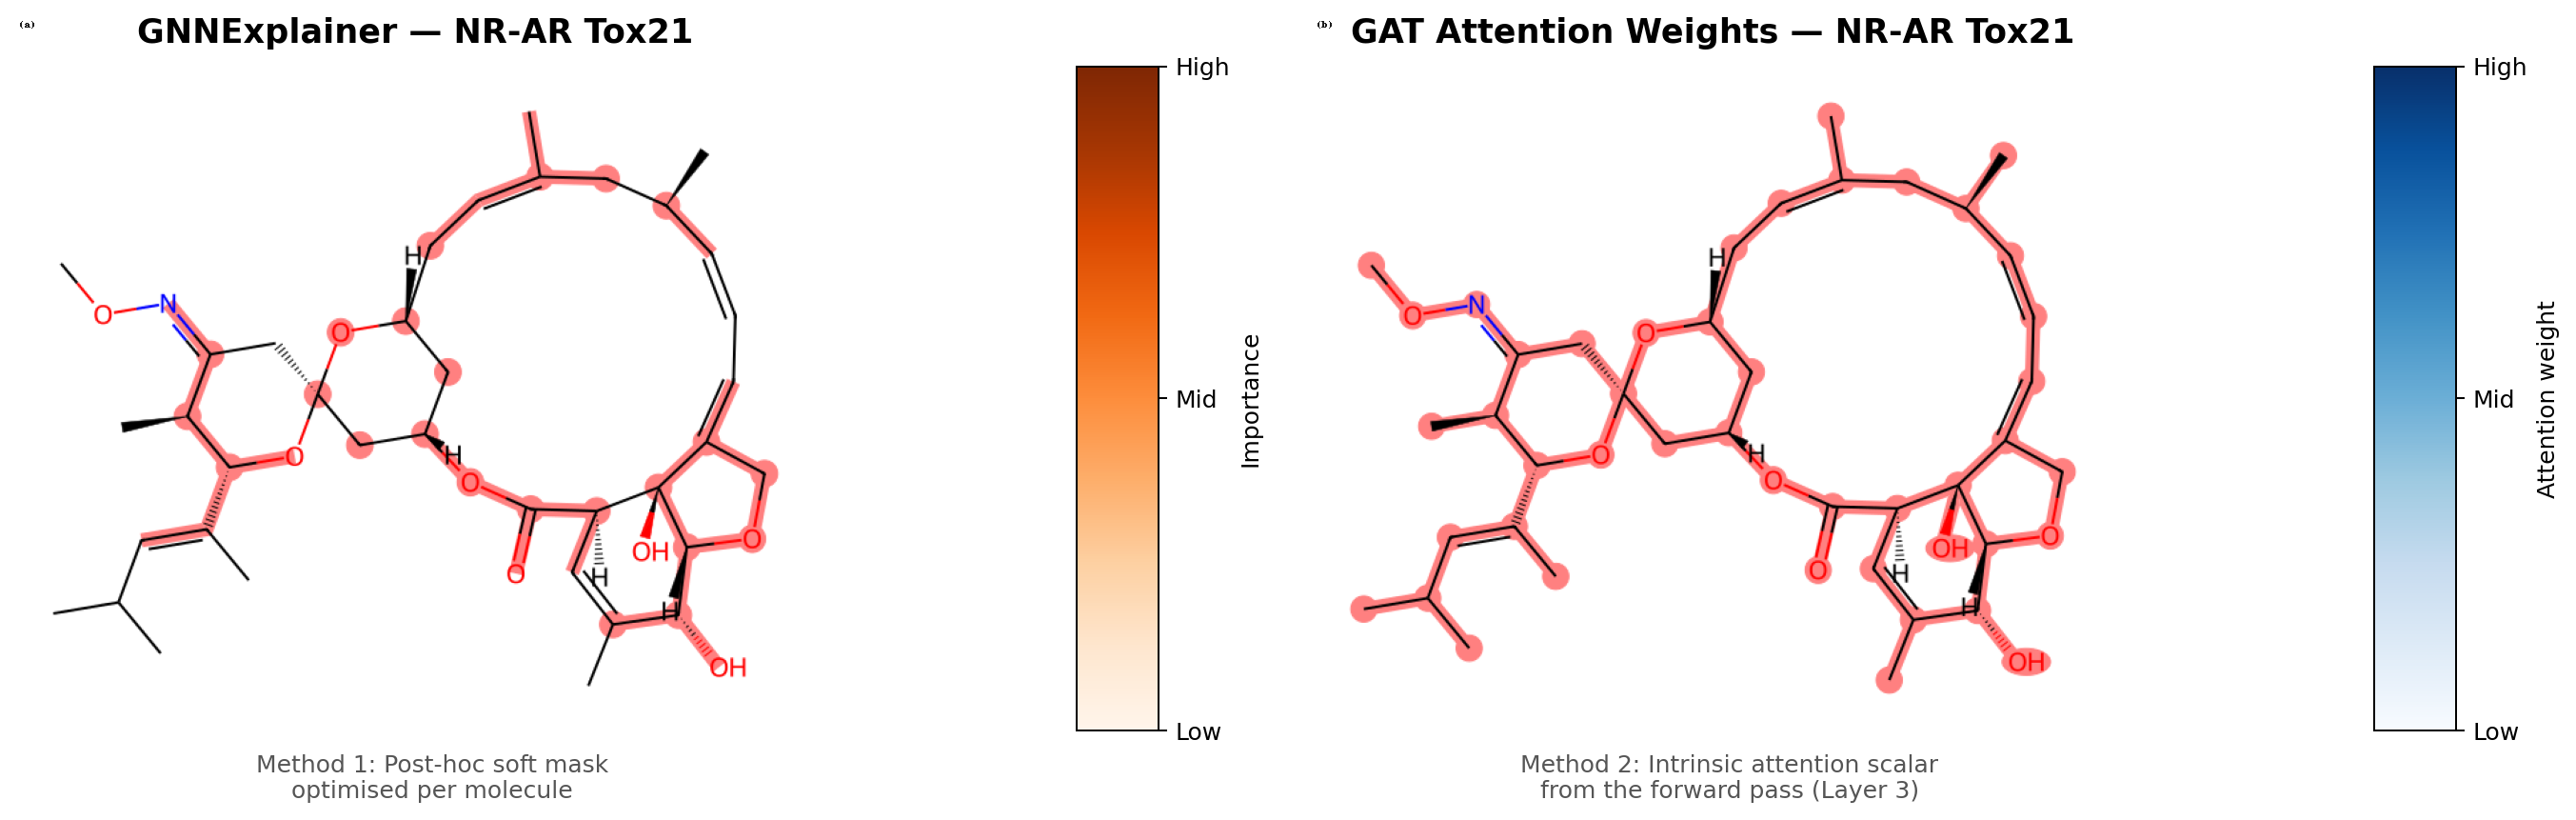

In [11]:
from PIL import Image as PILImage

img1 = PILImage.open('xai_figures/fig_method1_gnnexplainer.png')
img2 = PILImage.open('xai_figures/fig_method2_gat_attention.png')

# Make both the same height
target_h = min(img1.height, img2.height)
w1 = int(img1.width * target_h / img1.height)
w2 = int(img2.width * target_h / img2.height)
img1 = img1.resize((w1, target_h), PILImage.LANCZOS)
img2 = img2.resize((w2, target_h), PILImage.LANCZOS)

# Divider
gap = 20
combined_w = w1 + gap + w2
combined   = PILImage.new('RGB', (combined_w, target_h), color=(255, 255, 255))
combined.paste(img1, (0, 0))
combined.paste(img2, (w1 + gap, 0))

# Add (a) and (b) labels
from PIL import ImageDraw, ImageFont
draw_ctx = ImageDraw.Draw(combined)
try:
    font = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 28)
except:
    font = ImageFont.load_default()
draw_ctx.text((20, 20), '(a)', fill=(30, 30, 30), font=font)
draw_ctx.text((w1 + gap + 20, 20), '(b)', fill=(30, 30, 30), font=font)

PAPER_FIG_PATH = 'xai_figures/fig5_xai_comparison_PAPER.png'
combined.save(PAPER_FIG_PATH, dpi=(300, 300))

print(f'Paper figure saved: {PAPER_FIG_PATH}')
print(f'Dimensions        : {combined.size[0]} x {combined.size[1]} px')
display(Image(PAPER_FIG_PATH))

## Quantitative Faithfulness Check
Deletion faithfulness: remove the top-k important edges identified by
GNNExplainer and measure the change in predicted probability.

In [12]:
def deletion_faithfulness(model, data, edge_mask_np, device,
                          top_k_fractions=(0.10, 0.25, 0.50)):
    """
    Deletion faithfulness: measure how the predicted probability changes
    when the top-k most important edges (per GNNExplainer) are removed.
    A larger drop = higher faithfulness.
    """
    model.eval()
    results = []

    # Baseline probability (all edges present)
    with torch.no_grad():
        batch_vec = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
        logit_base = model(data.x, data.edge_index, batch_vec)
        prob_base  = torch.sigmoid(logit_base).item()

    n_edges = data.edge_index.shape[1]
    sorted_edges = np.argsort(edge_mask_np)[::-1]  # most important first

    for frac in top_k_fractions:
        k = max(1, int(frac * n_edges))
        remove_set = set(sorted_edges[:k].tolist())

        # Build reduced edge_index
        keep = [i for i in range(n_edges) if i not in remove_set]
        if len(keep) == 0:
            results.append((frac, prob_base, 0.0, prob_base))
            continue

        reduced_ei = data.edge_index[:, keep].to(device)

        with torch.no_grad():
            logit_red = model(data.x, reduced_ei, batch_vec)
            prob_red  = torch.sigmoid(logit_red).item()

        delta = prob_base - prob_red
        results.append((frac, prob_base, prob_red, delta))

    return results


faith_results = deletion_faithfulness(
    model, data.to(DEVICE), edge_mask, DEVICE
)

print('Deletion Faithfulness (GNNExplainer)')
print('=' * 50)
print(f'{"Top-k removed":>15} {"P(base)":>10} {"P(reduced)":>12} {"Delta":>8}')
print('-' * 50)
for frac, pb, pr, delta in faith_results:
    print(f'{frac*100:>14.0f}%  {pb:>10.4f}  {pr:>12.4f}  {delta:>8.4f}')

print()
print('Interpretation: a positive Delta means removing the identified')
print('subgraph reduced the predicted toxicity probability — confirming')
print('that GNNExplainer identified causally relevant substructures.')

Deletion Faithfulness (GNNExplainer)
  Top-k removed    P(base)   P(reduced)    Delta
--------------------------------------------------
            10%      0.8480        0.8445    0.0035
            25%      0.8480        0.8289    0.0191
            50%      0.8480        0.8159    0.0321

Interpretation: a positive Delta means removing the identified
subgraph reduced the predicted toxicity probability — confirming
that GNNExplainer identified causally relevant substructures.
